# Bacterial Isolate Analysis — Data Visualization

This notebook loads the outputs from the bioinformatics pipeline
(contig lengths, AMR gene detection, plasmid classification) and
creates the figures used in the findings report.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [3]:
contigs = pd.read_csv('../results/contig_lengths.tsv', sep='\t', header=None, names=['contig_id', 'length'], encoding='utf-16')
contigs

,contig_id,length
0,contig_1,9539
1,contig_10,41153
2,contig_11,18370
3,contig_12,80507
4,contig_14,44731
5,contig_15,79489
6,contig_18,1349
7,contig_4,5306074
8,contig_5,214836
9,contig_6,41786


In [5]:
molecule_type = {
    'contig_1': 'plasmid',
    'contig_10': 'plasmid',
    'contig_11': 'plasmid',
    'contig_12': 'plasmid',
    'contig_14': 'plasmid',
    'contig_15': 'plasmid',
    'contig_18': 'chromosome',
    'contig_4': 'chromosome',
    'contig_5': 'plasmid',
    'contig_6': 'chromosome',
    'contig_7': 'plasmid',
    'contig_9': 'plasmid',
    }

contigs['molecule_type'] = contigs['contig_id'].map(molecule_type)
contigs

,contig_id,length,molecule_type
0,contig_1,9539,plasmid
1,contig_10,41153,plasmid
2,contig_11,18370,plasmid
3,contig_12,80507,plasmid
4,contig_14,44731,plasmid
5,contig_15,79489,plasmid
6,contig_18,1349,chromosome
7,contig_4,5306074,chromosome
8,contig_5,214836,plasmid
9,contig_6,41786,chromosome


## Figure 1: Contig Sizes (Chromosome vs Plasmid)

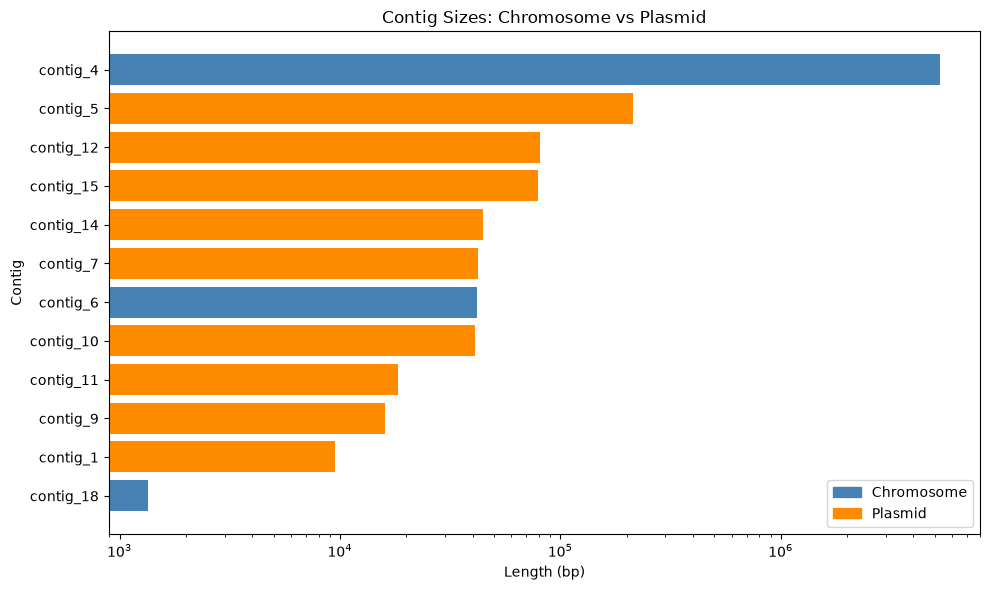

In [9]:
contigs_sorted = contigs.sort_values('length')
colors = contigs_sorted['molecule_type'].map({'chromosome': 'steelblue', 'plasmid': 'darkorange'})
plt.figure(figsize=(10, 6))
plt.barh(contigs_sorted['contig_id'], contigs_sorted['length'], color=colors)
chrom_patch = mpatches.Patch(color='steelblue', label='Chromosome')
plasmid_patch = mpatches.Patch(color='darkorange', label='Plasmid')
plt.legend(handles=[chrom_patch, plasmid_patch])
plt.xlabel('Length (bp)')
plt.xscale('log')
plt.ylabel('Contig')
plt.title('Contig Sizes: Chromosome vs Plasmid')
plt.tight_layout()
plt.savefig('../results/visualizations/contig_sizes.png', dpi=150)
plt.show()

In [11]:
card = pd.read_csv('../results/abricate_card.tsv', sep='\t', encoding='utf-16')
card.head()

,#FILE,SEQUENCE,START,END,STRAND,GENE,COVERAGE,COVERAGE_MAP,GAPS,%COVERAGE,%IDENTITY,DATABASE,ACCESSION,PRODUCT,RESISTANCE
0,/data/results/flye_assembly/assembly.fasta,contig_10,26609,27634,-,APH(4)-Ia,1-1026/1026,===============,0/0,100.0,100.00,card,V01499.1:230-1256,APH(4)-Ia is a plasmid-encoded aminoglycoside ...,aminoglycoside
1,/data/results/flye_assembly/assembly.fasta,contig_10,27863,28639,-,AAC(3)-IVa,1-777/777,===============,0/0,100.0,100.00,card,DQ241380.1:0-777,AAC(3)-IV is a plasmid-encoded aminoglycoside ...,aminoglycoside
2,/data/results/flye_assembly/assembly.fasta,contig_10,31530,32321,+,sul3,1-792/792,===============,0/0,100.0,100.00,card,FJ196385.1:9323-8531,Sul3 is a sulfonamide resistant dihydropteroat...,sulfonamide
3,/data/results/flye_assembly/assembly.fasta,contig_10,33501,33833,-,qacL,1-333/333,===============,0/0,100.0,91.59,card,DQ149925.1:188-521,A subunit of the qac multidrug efflux pump in ...,disinfecting_agents_and_antiseptics
4,/data/results/flye_assembly/assembly.fasta,contig_10,34003,34794,-,aadA,1-792/792,===============,0/0,100.0,99.75,card,AF550679.1:81768-80976,ANT(3'')-Ia is an aminoglycoside nucleotidyltr...,aminoglycoside


In [12]:
gene_counts = card['SEQUENCE'].value_counts()
gene_counts

SEQUENCE
contig_4     26
contig_5      8
contig_10     7
contig_15     5
contig_7      1
Name: count, dtype: int64

## Figure 2: AMR Gene Count per Contig

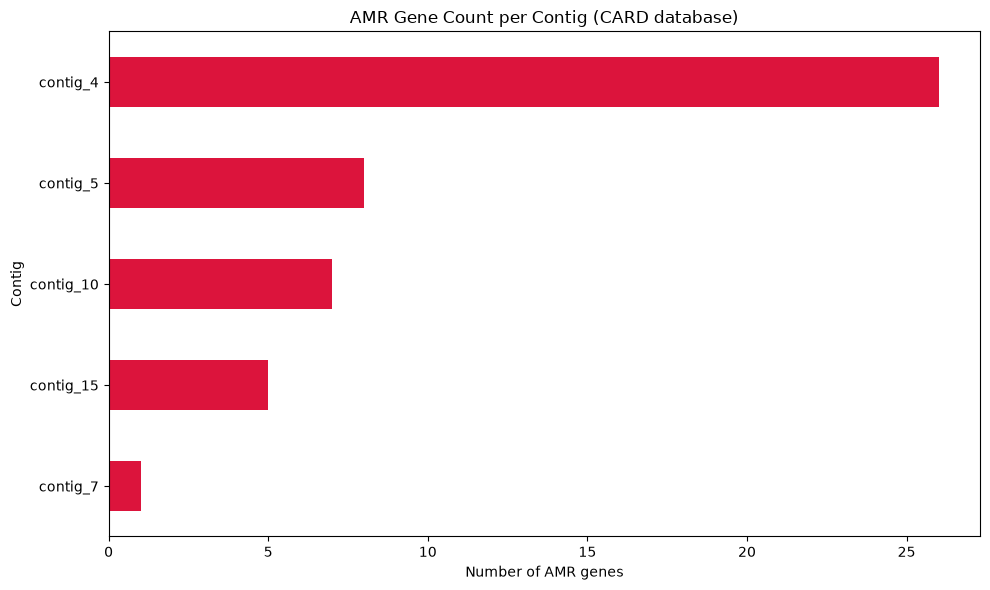

In [13]:
plt.figure(figsize=(10, 6))
gene_counts.sort_values().plot(kind='barh', color='crimson')
plt.xlabel('Number of AMR genes')
plt.ylabel('Contig')
plt.title('AMR Gene Count per Contig (CARD database)')
plt.tight_layout()
plt.savefig('../results/visualizations/amr_genes_per_contig.png', dpi=150)
plt.show()

In [14]:
card['RESISTANCE'].head(10)

0                                       aminoglycoside
1                                       aminoglycoside
2                                          sulfonamide
3                  disinfecting_agents_and_antiseptics
4                                       aminoglycoside
5                                             phenicol
6                                       aminoglycoside
7    carbapenem;cephalosporin;monobactam;penicillin...
8      cephalosporin;monobactam;penicillin_beta-lactam
9                               penicillin_beta-lactam
Name: RESISTANCE, dtype: str

In [15]:
resistance_split = card['RESISTANCE'].dropna().str.split(';').explode()
resistance_split

0                          aminoglycoside
1                          aminoglycoside
2                             sulfonamide
3     disinfecting_agents_and_antiseptics
4                          aminoglycoside
                     ...                 
43                         aminoglycoside
44                      diaminopyrimidine
45                               phenicol
46                          cephalosporin
46                 penicillin_beta-lactam
Name: RESISTANCE, Length: 134, dtype: str

In [16]:
resistance_counts = resistance_split.value_counts()
resistance_counts

RESISTANCE
cephalosporin                          15
penicillin_beta-lactam                 15
aminoglycoside                         14
fluoroquinolone                        11
tetracycline                            9
disinfecting_agents_and_antiseptics     8
carbapenem                              8
peptide                                 8
macrolide                               8
rifamycin                               7
phenicol                                6
monobactam                              6
glycylcycline                           6
aminocoumarin                           4
diaminopyrimidine                       3
sulfonamide                             2
nitrofuran                              2
nitroimidazole                          1
phosphonic_acid                         1
Name: count, dtype: int64

## Figure 3: Distribution of Resistance Classes

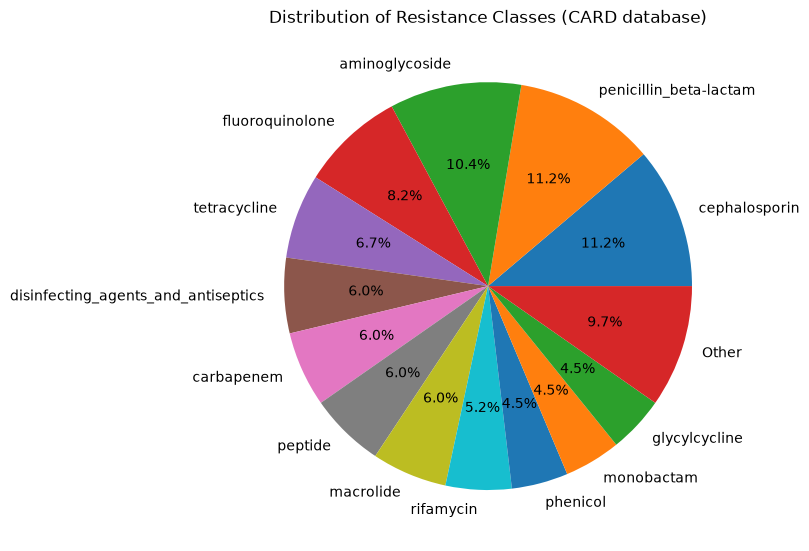

In [18]:
threshold = 3  # yüzde 3'ün altındakiler "Other" olacak
percentages = resistance_counts / resistance_counts.sum() * 100

major = resistance_counts[percentages >= threshold]
minor_sum = resistance_counts[percentages < threshold].sum()

final_counts = major.copy()
final_counts['Other'] = minor_sum

plt.figure(figsize=(8, 8))
plt.pie(final_counts, labels=final_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Resistance Classes (CARD database)')
plt.tight_layout()
plt.savefig('../results/visualizations/resistance_class_distribution.png', dpi=150)
plt.show()

In [19]:
molecule_totals = contigs.groupby('molecule_type')['length'].sum()
molecule_totals

molecule_type
chromosome    5349209
plasmid        547124
Name: length, dtype: int64